# **Analisis sobre transacciones del Banco XYZ**

**Ver archivo "proyecto-objetivos.md"**




## **Importacion de librerias**

In [242]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Carga de los datos**

In [243]:
df = pd.read_csv('../datos/brutos/train.csv', sep=',', encoding='latin-1', low_memory=False)

## EDA

 **Conocer los datos**

In [245]:
df.shape

(2965, 26)

In [246]:
df.head()

,id,FRAUDE,VALOR,HORA_AUX,Dist_max_NAL,Canal1,FECHA,COD_PAIS,CANAL,DIASEM,...,INGRESOS,EGRESOS,NROPAISES,Dist_Sum_INTER,Dist_Mean_INTER,Dist_Max_INTER,NROCIUDADES,Dist_Mean_NAL,Dist_HOY,Dist_sum_NAL
0,9000000001,1,0.0,13,659.13,ATM_INT,20150501,US,ATM_INT,5,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
1,9000000002,1,0.0,17,594.77,ATM_INT,20150515,US,ATM_INT,5,...,5643700.0,500000.0,1,NaN,NaN,NaN,5,289.99,4552.41,2029.90
2,9000000003,1,0.0,13,659.13,ATM_INT,20150501,US,ATM_INT,5,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
3,9000000004,1,0.0,13,659.13,ATM_INT,20150501,US,ATM_INT,5,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
4,9000000005,1,0.0,0,1.00,ATM_INT,20150510,CR,ATM_INT,0,...,0.0,0.0,1,NaN,NaN,NaN,1,NaN,1482.35,1.00


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2965 non-null   int64  
 1   FRAUDE           2965 non-null   int64  
 2   VALOR            2965 non-null   float64
 3   HORA_AUX         2965 non-null   int64  
 4   Dist_max_NAL     2965 non-null   float64
 5   Canal1           2965 non-null   object 
 6   FECHA            2965 non-null   int64  
 7   COD_PAIS         2965 non-null   object 
 8   CANAL            2965 non-null   object 
 9   DIASEM           2965 non-null   int64  
 10  DIAMES           2965 non-null   int64  
 11  FECHA_VIN        2941 non-null   float64
 12  OFICINA_VIN      2941 non-null   float64
 13  SEXO             2910 non-null   object 
 14  SEGMENTO         2941 non-null   object 
 15  EDAD             2941 non-null   float64
 16  INGRESOS         2941 non-null   float64
 17  EGRESOS       

In [248]:
df.isnull().sum()   

id                    0
FRAUDE                0
VALOR                 0
HORA_AUX              0
Dist_max_NAL          0
Canal1                0
FECHA                 0
COD_PAIS              0
CANAL                 0
DIASEM                0
DIAMES                0
FECHA_VIN            24
OFICINA_VIN          24
SEXO                 55
SEGMENTO             24
EDAD                 24
INGRESOS             24
EGRESOS              24
NROPAISES             0
Dist_Sum_INTER     1547
Dist_Mean_INTER    1547
Dist_Max_INTER     1547
NROCIUDADES           0
Dist_Mean_NAL       457
Dist_HOY              0
Dist_sum_NAL          0
dtype: int64

In [ ]:
# elimar del df las columnas hora_aux y fecha
df_sin_duplicadosdf = df.drop(columns=['HORA_AUX', 'FECHA'])

In [254]:
df_sin_duplicados = df.drop_duplicates()

In [256]:
df_sin_duplicados

,id,FRAUDE,VALOR,Dist_max_NAL,Canal1,COD_PAIS,CANAL,DIASEM,DIAMES,FECHA_VIN,...,INGRESOS,EGRESOS,NROPAISES,Dist_Sum_INTER,Dist_Mean_INTER,Dist_Max_INTER,NROCIUDADES,Dist_Mean_NAL,Dist_HOY,Dist_sum_NAL
0,9000000001,1,0.00,659.13,ATM_INT,US,ATM_INT,5,1,20120306.0,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
1,9000000002,1,0.00,594.77,ATM_INT,US,ATM_INT,5,15,20050415.0,...,5643700.0,500000.0,1,NaN,NaN,NaN,5,289.99,4552.41,2029.90
2,9000000003,1,0.00,659.13,ATM_INT,US,ATM_INT,5,1,20120306.0,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
3,9000000004,1,0.00,659.13,ATM_INT,US,ATM_INT,5,1,20120306.0,...,1200000.0,1200000.0,1,NaN,NaN,NaN,6,474.94,4552.41,5224.36
4,9000000005,1,0.00,1.00,ATM_INT,CR,ATM_INT,0,10,20141009.0,...,0.0,0.0,1,NaN,NaN,NaN,1,NaN,1482.35,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2960,622529101,1,993430.04,180.65,POS,US,POS,2,19,19740401.0,...,103918285.0,95475378.0,4,8944.83,2236.21,3646.67,4,96.86,4552.41,484.30
2961,2043206272,0,9957.05,318.50,POS,US,POS,0,24,19970616.0,...,23625000.0,5000000.0,3,27648.32,3949.76,4552.41,11,82.67,4552.41,2810.75
2962,2943206272,0,9957.05,318.50,POS,US,POS,0,24,19970616.0,...,23625000.0,5000000.0,3,27648.32,3949.76,4552.41,11,82.67,4552.41,2810.75
2963,3136302872,0,996191.64,234.42,POS,US,MCI,3,13,20000609.0,...,56666000.0,37600750.0,1,NaN,NaN,NaN,3,219.46,4552.41,1316.79


In [255]:
df.duplicated().sum()

np.int64(7)

**Analisis univariado**

Variables categoricas

In [257]:
df_sin_duplicados['FRAUDE'].value_counts()

FRAUDE
0    2232
1     726
Name: count, dtype: int64

In [289]:
df_sin_duplicados['SEXO'].value_counts()

SEXO
F    1489
M    1469
Name: count, dtype: int64

In [290]:
df_sin_duplicados['SEGMENTO'].value_counts()

SEGMENTO
Personal Plus    1545
Preferencial      957
Personal          174
Emprendedor       159
PYME              119
Empresarial         4
Name: count, dtype: int64

In [291]:
df_sin_duplicados['CANAL'].value_counts()

CANAL
MCI        1199
POS        1125
ATM_INT     634
Name: count, dtype: int64

In [292]:
df_sin_duplicados['Canal1'].value_counts()

Canal1
POS        2324
ATM_INT     634
Name: count, dtype: int64

In [296]:
df_sin_duplicados['COD_PAIS'].value_counts().nunique()


15

**Converción tipo de dato object a categorica**

In [297]:
# Evita SettingWithCopyWarning: trabaja sobre una copia y usa .loc
df_sin_duplicados = df_sin_duplicados.copy()

df_sin_duplicados.loc[:, 'FRAUDE'] = df_sin_duplicados['FRAUDE'].astype('category')
df_sin_duplicados.loc[:, 'Canal1'] = df_sin_duplicados['Canal1'].astype('category')
df_sin_duplicados.loc[:, 'SEXO'] = df_sin_duplicados['SEXO'].astype('category')
df_sin_duplicados.loc[:, 'SEGMENTO'] = df_sin_duplicados['SEGMENTO'].astype('category')
df_sin_duplicados.loc[:, 'COD_PAIS'] = df_sin_duplicados['COD_PAIS'].astype('category')

In [329]:
# imputacion de la valiable Sexo con la moda por F
df_sin_duplicados['SEXO'] = df_sin_duplicados['SEXO'].fillna(df_sin_duplicados['SEXO'].mode()[0])

In [330]:
# imputación de la variable Segmento con personal plus
df_sin_duplicados["SEGMENTO"] = df_sin_duplicados["SEGMENTO"].fillna(df_sin_duplicados["SEGMENTO"].mode()[0])

In [331]:
# convertir las columnas FECHA_VIN a tipo fecha y hora
df_sin_duplicados['FECHA_VIN'] = pd.to_datetime(df_sin_duplicados['FECHA_VIN'], format='%Y-%m-%d', errors='coerce')

In [332]:
# imputacion de la variable FECHA_VIN con la fecha 2020-01-01
df_sin_duplicados.loc[:, 'FECHA_VIN'] = df_sin_duplicados['FECHA_VIN'].fillna(pd.to_datetime('2020-01-01', format='%Y-%m-%d'))

Variables numericas

In [333]:
df_sin_duplicados[['EDAD', 'INGRESOS', 'EGRESOS', 'OFICINA_VIN', 'Dist_Mean_NAL']].describe()

,EDAD,INGRESOS,EGRESOS,OFICINA_VIN,Dist_Mean_NAL
count,2958.000000,2.958000e+03,2.958000e+03,2958.000000,2958.000000
mean,40.009804,1.444531e+07,8.471351e+06,415.636241,185.586988
std,12.936184,5.621386e+07,6.161540e+07,289.185581,177.909335
min,0.000000,0.000000e+00,0.000000e+00,1.000000,4.480000
25%,31.000000,2.507426e+06,5.000000e+05,171.000000,69.660000
50%,38.000000,5.900000e+06,1.950000e+06,360.000000,127.580000
75%,47.000000,1.274000e+07,4.500000e+06,658.000000,236.015000
max,133.000000,1.940070e+09,1.600000e+09,967.000000,1217.570000


In [334]:
# imputacion de valores nulos en las variables nuericas con la mediana
df_sin_duplicados['EDAD'] = df_sin_duplicados['EDAD'].fillna(df_sin_duplicados['EDAD'].median())
df_sin_duplicados['INGRESOS'] = df_sin_duplicados['INGRESOS'].fillna(df_sin_duplicados['INGRESOS'].median())
df_sin_duplicados['EGRESOS'] = df_sin_duplicados['EGRESOS'].fillna(df_sin_duplicados['EGRESOS'].median())
df_sin_duplicados['OFICINA_VIN'] = df_sin_duplicados['OFICINA_VIN'].fillna(df_sin_duplicados['OFICINA_VIN'].median())
df_sin_duplicados['Dist_Mean_NAL'] = df_sin_duplicados['Dist_Mean_NAL'].fillna(df_sin_duplicados['Dist_Mean_NAL'].median())

**Datos limpios**
Nota: aun mo sabemos para que no serviran las variables (Dist_Sum_INTER, Dist_Mean_INTER, Dist_Max_INTER), cada uno con 1547 datos nulos.

In [337]:
df_sin_duplicados.isnull().sum()

id                    0
FRAUDE                0
VALOR                 0
Dist_max_NAL          0
Canal1                0
COD_PAIS              0
CANAL                 0
DIASEM                0
DIAMES                0
FECHA_VIN             0
OFICINA_VIN           0
SEXO                  0
SEGMENTO              0
EDAD                  0
INGRESOS              0
EGRESOS               0
NROPAISES             0
Dist_Sum_INTER     1541
Dist_Mean_INTER    1541
Dist_Max_INTER     1541
NROCIUDADES           0
Dist_Mean_NAL         0
Dist_HOY              0
Dist_sum_NAL          0
dtype: int64

**Gráficos de variables categoricas**

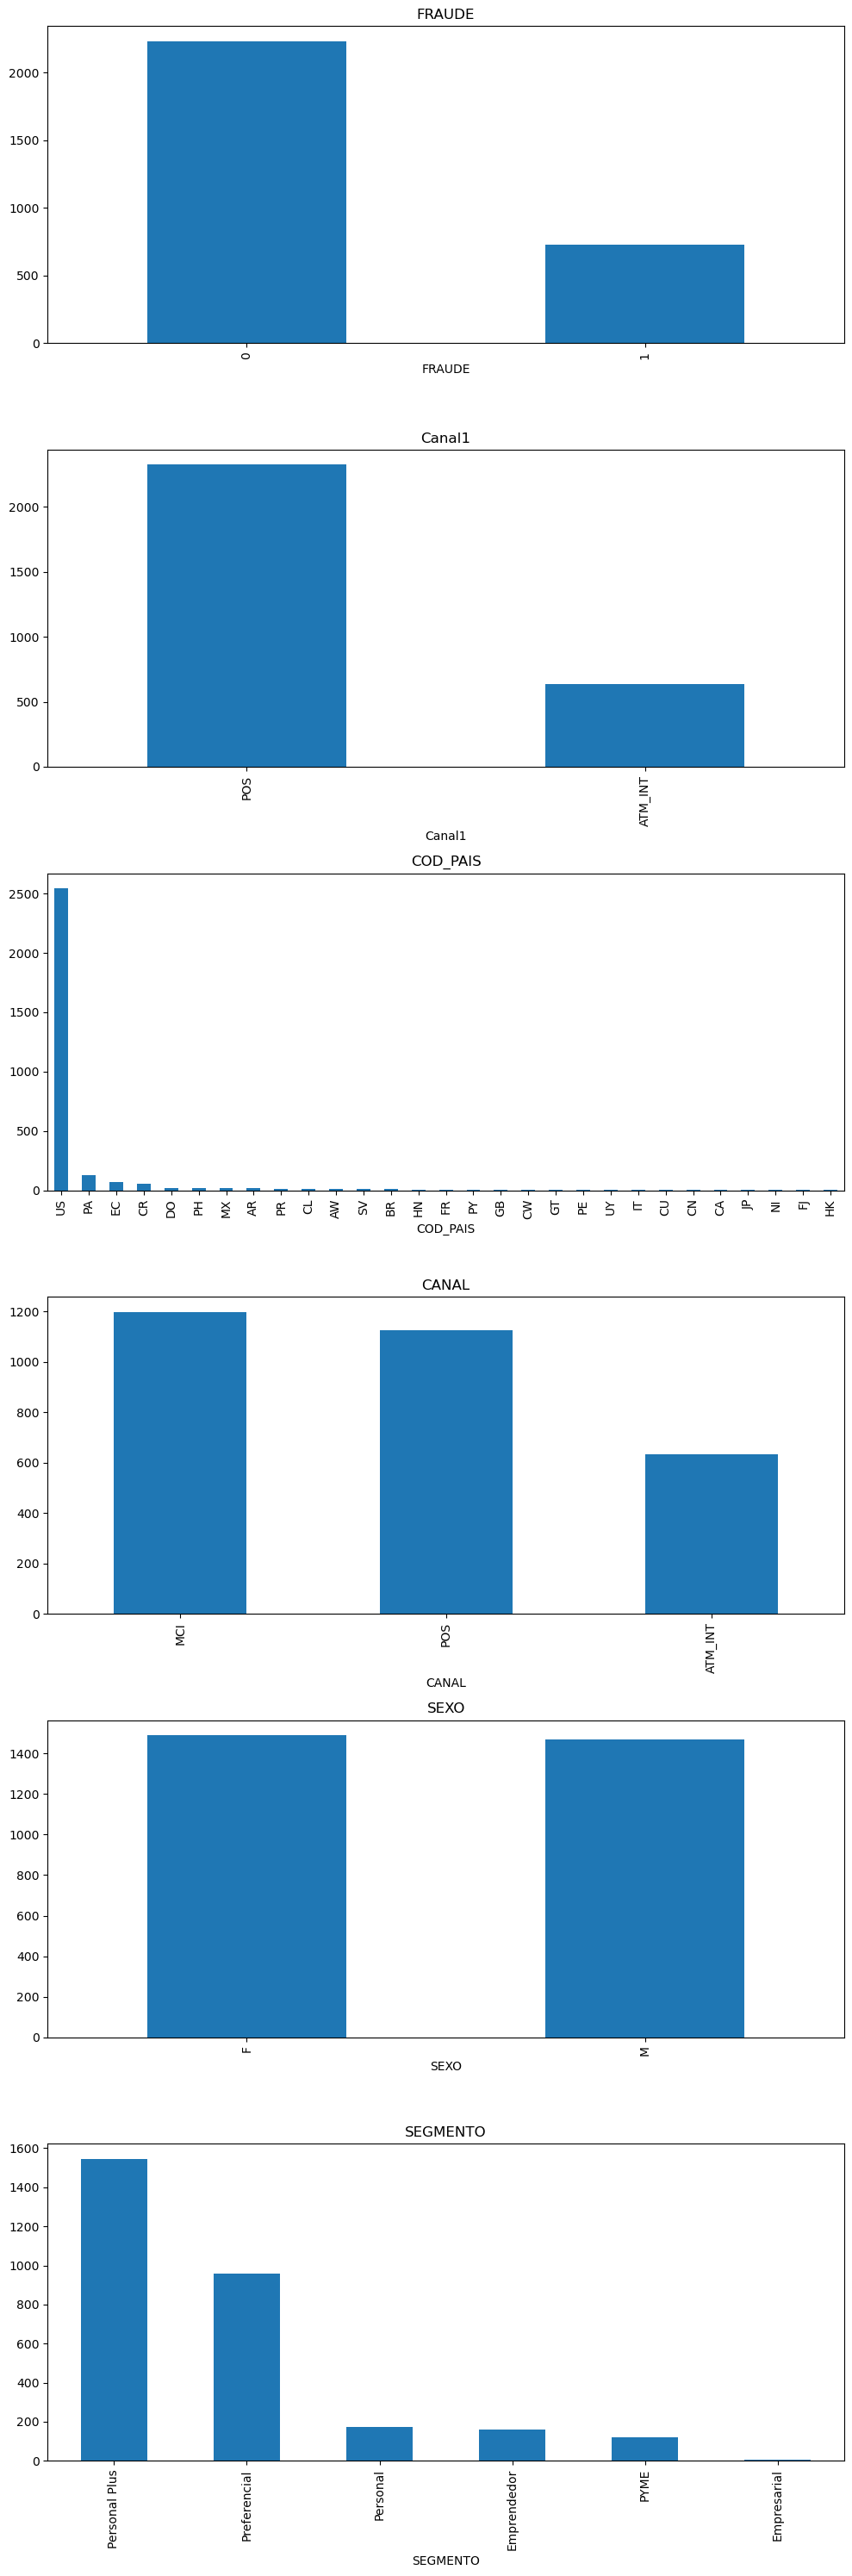

In [338]:
# genera un grafico con las variables categoricas y su distribucion de valores
categoricas = df_sin_duplicados.select_dtypes(include=["object", "category"]).columns

fig, axes = plt.subplots(len(categoricas), 1, figsize=(10, 5 * len(categoricas)))
for ax, col in zip(axes, categoricas):
    df_sin_duplicados[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Gráficos de variables númericas**

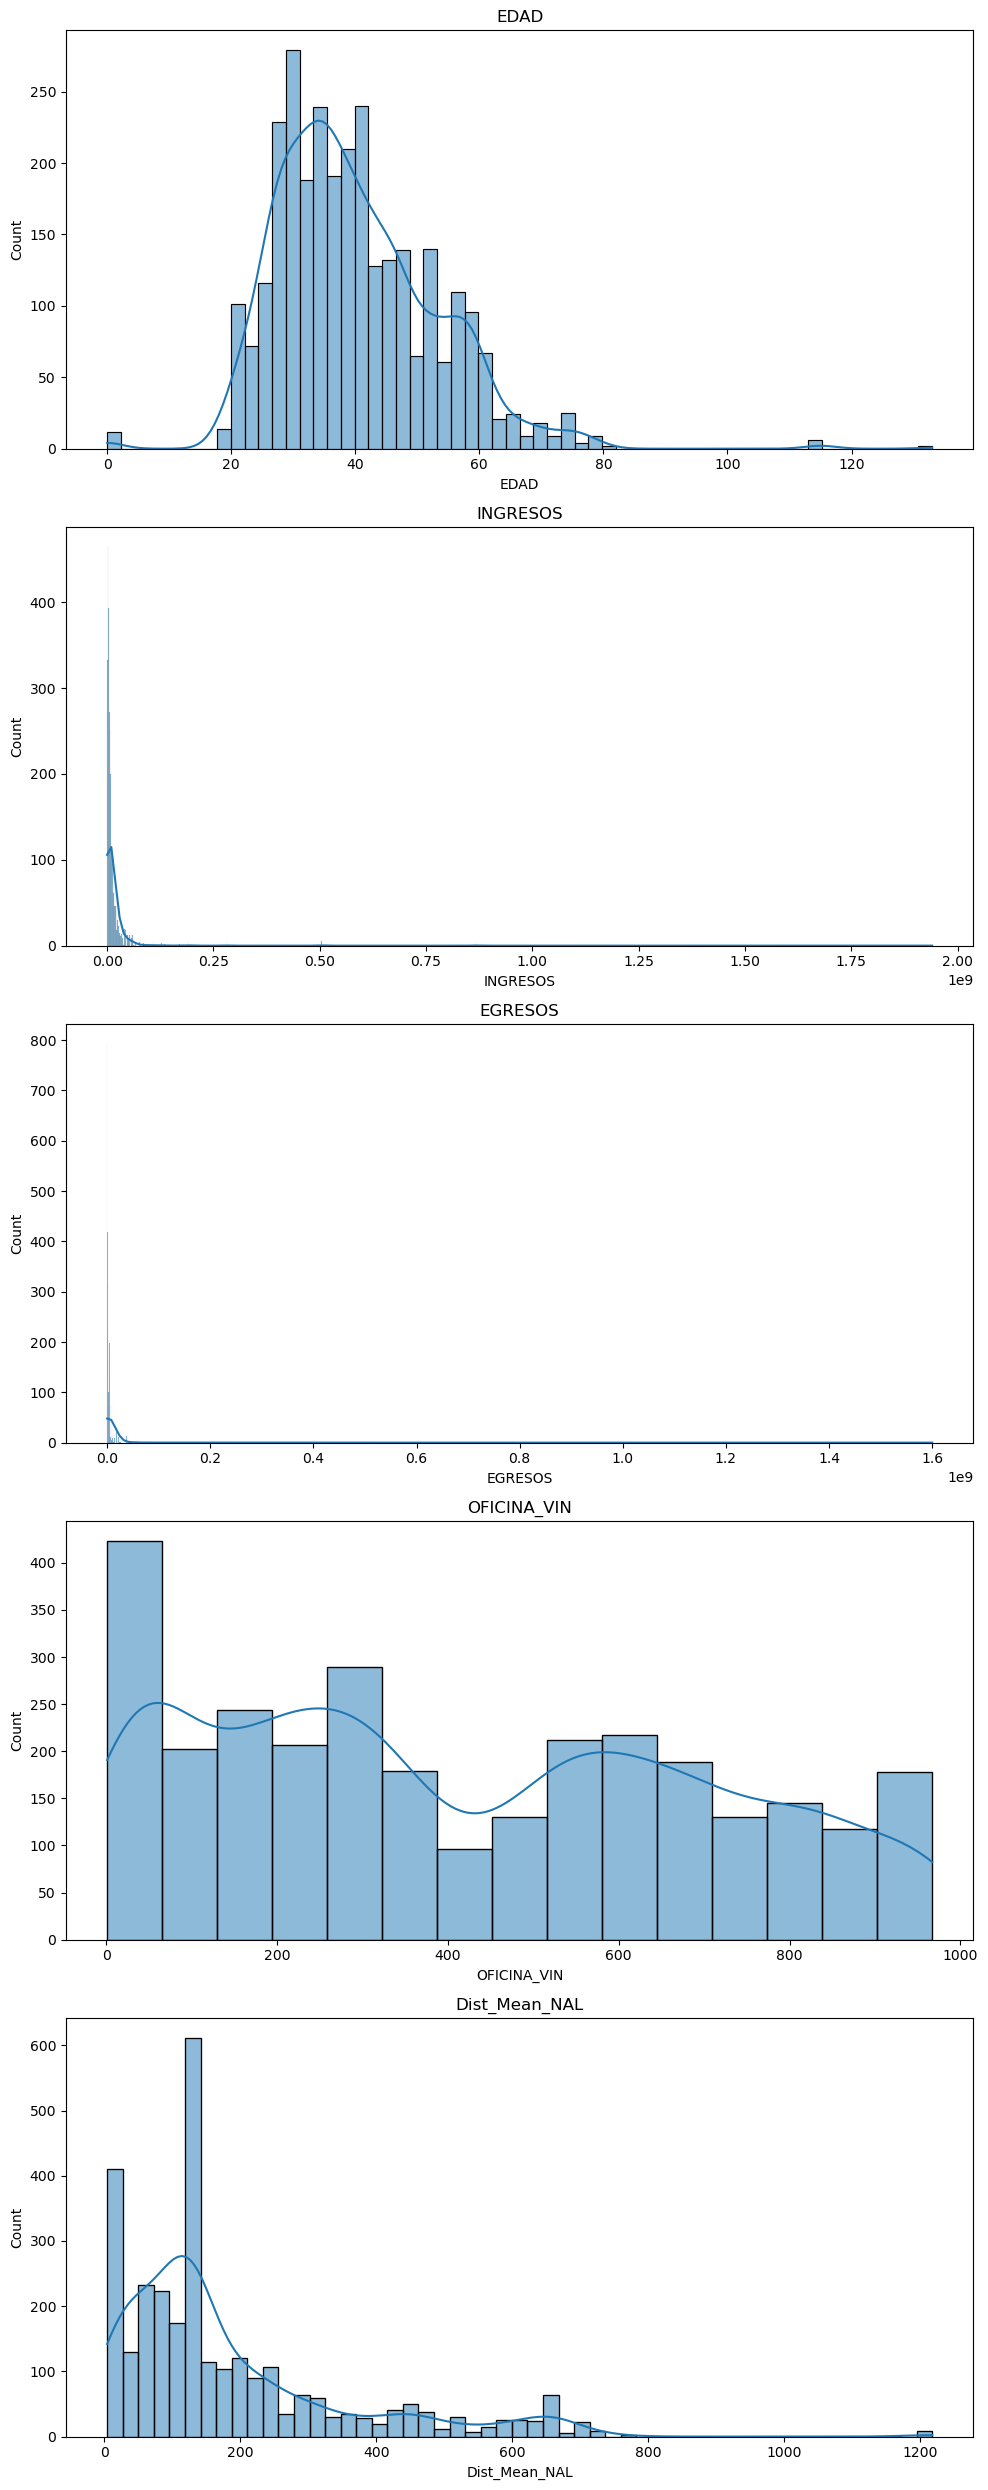

In [341]:
numericas = df_sin_duplicados[['EDAD', 'INGRESOS', 'EGRESOS', 'OFICINA_VIN', 'Dist_Mean_NAL']].columns 
fig, axes = plt.subplots(len(numericas), 1, figsize=(10, 5 * len(numericas)))
for ax, col in zip(axes, numericas):
    sns.histplot(df_sin_duplicados[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Analisis Bivariado**

Fraude con categoricas

In [342]:
tabla1_sexo = pd.crosstab(df['SEXO'], df['FRAUDE'], normalize='index')*100
tabla1_sexo

FRAUDE,0,1
SEXO,,
F,72.461752,27.538248
M,77.853261,22.146739


In [343]:
tabla1_seg= pd.crosstab(df['SEGMENTO'], df['FRAUDE'], normalize='index')*100
tabla1_seg

FRAUDE,0,1
SEGMENTO,,
Emprendedor,71.069182,28.930818
Empresarial,100.000000,0.000000
PYME,95.798319,4.201681
Personal,55.747126,44.252874
Personal Plus,69.825919,30.174081
Preferencial,85.908142,14.091858


In [344]:
tabla1_CAN = pd.crosstab(df['CANAL'], df['FRAUDE'], normalize='index')*100
tabla1_CAN

FRAUDE,0,1
CANAL,,
ATM_INT,32.075472,67.924528
MCI,87.666667,12.333333
POS,86.625332,13.374668


In [345]:
tabla1_canal1 = pd.crosstab(df['Canal1'], df['FRAUDE'], normalize='index')*100
tabla1_canal1

FRAUDE,0,1
Canal1,,
ATM_INT,32.075472,67.924528
POS,87.161872,12.838128


In [346]:
tabla1_cod = pd.crosstab(df['FRAUDE'], df['COD_PAIS'], normalize='index')*100
tabla1_cod.sort_values(by=1, axis=1, ascending=False, inplace=True)
tabla1_cod

COD_PAIS,US,EC,CR,PA,PH,MX,CL,SV,HN,BR,...,AR,CA,FJ,CU,AW,JP,PR,PE,PY,UY
FRAUDE,,,,,,,,,,,,,,,,,,,,,
0,91.047449,0.671441,0.089526,4.789615,0.000000,0.089526,0.179051,0.000000,0.000000,0.044763,...,0.671441,0.089526,0.044763,0.089526,0.447628,0.089526,0.537153,0.134288,0.268577,0.134288
1,70.451436,7.523940,7.387141,2.599179,2.051984,1.778386,1.231190,1.094391,0.957592,0.957592,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [347]:
tabla1_NROciu = pd.crosstab(df['FRAUDE'], df['NROCIUDADES'], normalize='index')*100
tabla1_NROciu.sort_values(by=1, axis=1, ascending=False, inplace=True)
tabla1_NROciu

NROCIUDADES,2,1,3,4,5,6,8,7,9,15,12,11,10,13,14,17,19,20
FRAUDE,,,,,,,,,,,,,,,,,,
0,17.367950,13.697404,18.666070,17.547001,10.608774,6.356312,3.312444,6.624888,2.059087,0.00000,0.626679,0.940018,0.358102,0.80573,0.089526,0.313339,0.089526,0.537153
1,21.067031,20.656635,18.057456,13.269494,9.986320,5.745554,3.967168,3.830369,1.778386,1.23119,0.273598,0.136799,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


Fraude con Númericas

In [348]:
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89"]

tabla = df["RANGO_EDAD"] = pd.cut(
    df["EDAD"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
tabla0_edad = pd.crosstab(
    df["RANGO_EDAD"],
    df["FRAUDE"],
    normalize="index"
) * 100

tabla0_edad

FRAUDE,0,1
RANGO_EDAD,,
20-29,68.451520,31.548480
30-39,72.991968,27.008032
40-49,82.588598,17.411402
50-59,85.681818,14.318182
60-69,73.584906,26.415094
70-79,67.346939,32.653061


In [349]:
df['RANGO_EDAD'].value_counts()

RANGO_EDAD
30-39    996
20-29    691
40-49    649
50-59    440
60-69    106
70-79     49
80-89      0
Name: count, dtype: int64

In [350]:
bins = [0, 2000000, 5000000, 10000000, 20000000, float("inf")]
labels = ["0-2M", "2M-5M", "5M-10M", "10M-20M", ">20M"]

tabla = df["RANGO_INGRESOS"] = pd.cut(
    df["INGRESOS"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
tabla0_ingresos = pd.crosstab(
    df["RANGO_INGRESOS"],
    df["FRAUDE"],
    normalize="index"
) * 100

tabla0_ingresos

FRAUDE,0,1
RANGO_INGRESOS,,
0-2M,59.124088,40.875912
2M-5M,74.671446,25.328554
5M-10M,75.109170,24.890830
10M-20M,86.270492,13.729508
>20M,85.925926,14.074074


In [351]:
bins = [0, 1000000, 2000000, 5000000, 10000000, float("inf")]
labels = ["0-1M", "1M-2M", "2M-5M", "5M-10M", "10M+"]

tabla = df["RANGO_EGRESOS"] = pd.cut(
    df["EGRESOS"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
tabla0_egresos = pd.crosstab(
    df["RANGO_EGRESOS"],
    df["FRAUDE"],
    normalize="index"
) * 100

tabla0_egresos

FRAUDE,0,1
RANGO_EGRESOS,,
0-1M,67.140468,32.859532
1M-2M,78.857143,21.142857
2M-5M,75.976845,24.023155
5M-10M,86.206897,13.793103
10M+,92.015209,7.984791


**Grafico variable FRAUDE vs Númericas**

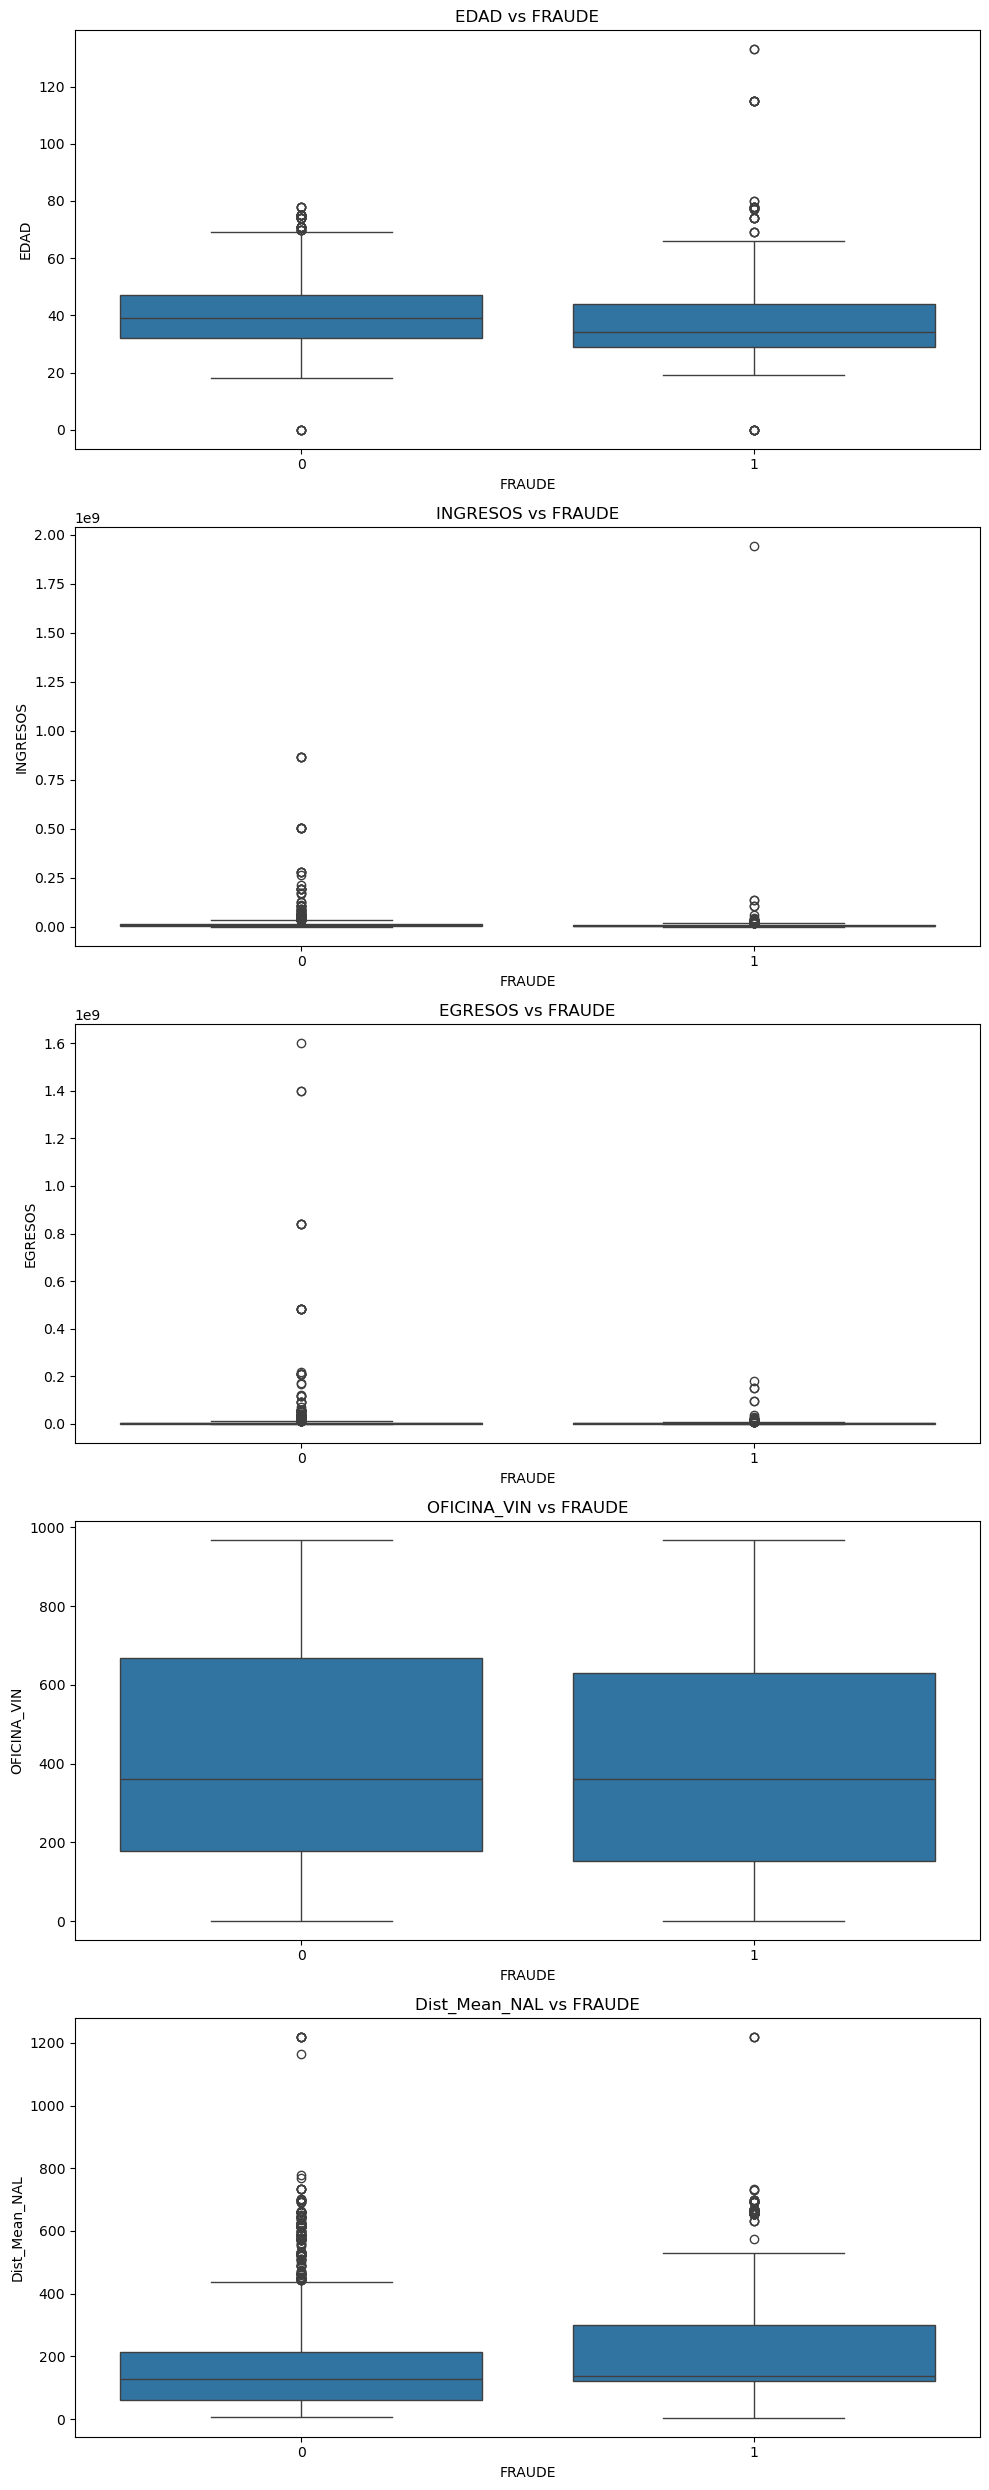

In [352]:
numericas = numericas = df[['EDAD', 'INGRESOS', 'EGRESOS', 'OFICINA_VIN', 'Dist_Mean_NAL']].columns 

# Crear la figura
fig, axes = plt.subplots(len(numericas), 1, figsize=(10, 5 * len(numericas)))

# Graficar cada variable vs FRAUDE
for ax, col in zip(axes, numericas):
    sns.boxplot(data=df, x="FRAUDE", y=col, ax=ax)
    ax.set_title(f"{col} vs FRAUDE")

plt.tight_layout()
plt.show()

## **Business Analytics**

1. ¿Cuál es la proporción de transacciones fraudulentas respecto al total de operaciones?

CÁLCULO DE KPIs PRINCIPALES

In [353]:
total_transacciones = len(df)
total_fraudes = (df['FRAUDE'] == 1).sum()
tasa_fraude = total_fraudes / total_transacciones * 100

In [354]:
print(f"Total de transacciones: {total_transacciones}")
print(f"Total de fraudes: {total_fraudes}")
print(f"Tasa de fraude: {tasa_fraude:.2f}%")

Total de transacciones: 2965
Total de fraudes: 731
Tasa de fraude: 24.65%


2. ¿Existen segmentos de clientes con mayor incidencia de fraude?

ANÁLISIS DE DISTRIBUCIÓN DEL FRAUDE

El analisis indica que en el segmento "Personal" existe un fraude de un 44.252% 

In [355]:
tabla1_seg

FRAUDE,0,1
SEGMENTO,,
Emprendedor,71.069182,28.930818
Empresarial,100.000000,0.000000
PYME,95.798319,4.201681
Personal,55.747126,44.252874
Personal Plus,69.825919,30.174081
Preferencial,85.908142,14.091858


Que el CANAL donde se produce mas fraude es "ATM_INT" con un 67.924%

In [357]:
tabla1_CAN

FRAUDE,0,1
CANAL,,
ATM_INT,32.075472,67.924528
MCI,87.666667,12.333333
POS,86.625332,13.374668


Es igual que el anterior

In [358]:
tabla1_canal1

FRAUDE,0,1
Canal1,,
ATM_INT,32.075472,67.924528
POS,87.161872,12.838128


EL pais donde ocurre mayor fraude es US con un 70.451%

In [359]:
tabla1_cod

COD_PAIS,US,EC,CR,PA,PH,MX,CL,SV,HN,BR,...,AR,CA,FJ,CU,AW,JP,PR,PE,PY,UY
FRAUDE,,,,,,,,,,,,,,,,,,,,,
0,91.047449,0.671441,0.089526,4.789615,0.000000,0.089526,0.179051,0.000000,0.000000,0.044763,...,0.671441,0.089526,0.044763,0.089526,0.447628,0.089526,0.537153,0.134288,0.268577,0.134288
1,70.451436,7.523940,7.387141,2.599179,2.051984,1.778386,1.231190,1.094391,0.957592,0.957592,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


¿Hay rangos de ingresos o edades donde el fraude sea más frecuente?

ANÁLISIS DE PERFILES

Los datos indican que el rango de edad donde ocurre el fraude es entre los 20 - 29 años con 31.54% y e los 70 - 79 años con un 32.65%

In [360]:
tabla0_edad

FRAUDE,0,1
RANGO_EDAD,,
20-29,68.451520,31.548480
30-39,72.991968,27.008032
40-49,82.588598,17.411402
50-59,85.681818,14.318182
60-69,73.584906,26.415094
70-79,67.346939,32.653061


EL 27% de los casos las mujeres incurren en fraude

In [362]:
tabla1_sexo

FRAUDE,0,1
SEXO,,
F,72.461752,27.538248
M,77.853261,22.146739


Los datos indican que en los ingresos entre 0 y 2M ocurre fraude en 40.87%

In [361]:
tabla0_ingresos

FRAUDE,0,1
RANGO_INGRESOS,,
0-2M,59.124088,40.875912
2M-5M,74.671446,25.328554
5M-10M,75.109170,24.890830
10M-20M,86.270492,13.729508
>20M,85.925926,14.074074


Para los egresos indica un mayor fraude para el rango de 0 a 1M, 

In [363]:
tabla0_egresos

FRAUDE,0,1
RANGO_EGRESOS,,
0-1M,67.140468,32.859532
1M-2M,78.857143,21.142857
2M-5M,75.976845,24.023155
5M-10M,86.206897,13.793103
10M+,92.015209,7.984791


Las variables numericas no aportan datos significativos para la prediicion de la variable objetivo, pero si aportan mas valor para caracterizacion del perfil de usuarios.

¿Existen diferencias significativas entre países o regiones?



In [364]:
tabla1_cod

COD_PAIS,US,EC,CR,PA,PH,MX,CL,SV,HN,BR,...,AR,CA,FJ,CU,AW,JP,PR,PE,PY,UY
FRAUDE,,,,,,,,,,,,,,,,,,,,,
0,91.047449,0.671441,0.089526,4.789615,0.000000,0.089526,0.179051,0.000000,0.000000,0.044763,...,0.671441,0.089526,0.044763,0.089526,0.447628,0.089526,0.537153,0.134288,0.268577,0.134288
1,70.451436,7.523940,7.387141,2.599179,2.051984,1.778386,1.231190,1.094391,0.957592,0.957592,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


En la ciudad 2 ocurre el 21.067% de los fraudes

In [365]:
tabla1_NROciu

NROCIUDADES,2,1,3,4,5,6,8,7,9,15,12,11,10,13,14,17,19,20
FRAUDE,,,,,,,,,,,,,,,,,,
0,17.367950,13.697404,18.666070,17.547001,10.608774,6.356312,3.312444,6.624888,2.059087,0.00000,0.626679,0.940018,0.358102,0.80573,0.089526,0.313339,0.089526,0.537153
1,21.067031,20.656635,18.057456,13.269494,9.986320,5.745554,3.967168,3.830369,1.778386,1.23119,0.273598,0.136799,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


Los dadtos infdicacan que en el pais US ocurren el 70.451 de los casos de fraude

**Insight importantes**


¿Qué variables parecen estar más relacionadas con la ocurrencia de fraude?

Las variables que estan mas asociadas a la oocurrencia de fraude son:
COD_PAIS = 70.451
CANAL = 67.924%
Canal1 = 67.924%
SEGEMENTO = 44.252%

El análisis indica que las variables CANAL, SEGMENTO y COD_PAIS son las que presentan la relación más consistente con la ocurrencia de fraude en este conjunto de datos. Estas variables constituyen los principales candidatos para fortalecer las reglas de monitoreo y para el desarrollo de futuros modelos predictivos. Variables como EDAD, INGRESOS y EGRESOS aportan información complementaria para caracterizar el perfil de los clientes, pero no evidencian por sí solas una relación suficientemente fuerte como para explicar el fraude.